# **Graph Neural Networks**

## Assignment Number : 7

- **Student Name**: Sanjay Pahari
- **Roll Number**: 42
- **Group**: Computer Engineering, 7th semester
- **Date**: 17 March 2026
- **Dataset Used**: Cora Citation Network Dataset
- **Personal Note**: https://freaktopus.github.io/LearningDeep
- **Resource Utilized**: Graph Neural Networks in Action (Manning), PyTorch Geometric Docs, D2L.ai
- **Acknowledgement**: Some code snippets were copied from LLM to reduce implementation burden in section like graph ploting and EDA. The primary intent was to understand overall architectire and working of GNN.

## **Objective**
This assigment focuses on understanding and implementing Graph Convolutional Networks for semi supervised node classification. The objectives are listed below: 

1. Get understanding of following concepts: GCN, GNN, and message passing across nodes
2. Implemenation of GCN layers
3. Build multi layer GCN classifiers on Cora citation graph
4. Visulise the learned node embedding

## **Theoretical Background**

Let's dive little deeper Graph, Graph COnvolution NEtworks, Message passing interpretation, and Semisupervised Node Classification.

### Graph

Graph consist of node and edge; i.e. G=(V,E). In node classification, every node carries a feature vector and a label. The graph topology is encoded in the adjacency matrix. 

![Fig: Graph](../../assets/7/graph.png)

### Graph Convolution Networks (GCN)

Based in Kipf et al. 2017, Aggregating the neighbors node features and training the weights with Message Passing Scheme, we can build GCN.


![Fig: Graph](../../assets/7/gcn.png)
![Fig: Graph](../../assets/7/gcn1.png)
![Fig: Graph](../../assets/7/gcn2.png)
![Fig: Graph](../../assets/7/gcn2.png)

CCN is also a Message Passing GNN

Here is the illustration of that:  

![Fig: Graph](../../assets/7/cnn.png)



## **Implementation**

So, we will be using penn-fudan pedestrian detection & segmentation dataset. And we will implement transfer learning on it and also experiment with it with hyperparameter modification.

### **Step 1: Initialization**

In [28]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# import tensorflow as tf

from pathlib import Path

np.random.seed(42)
# tf.random.set_seed(42)

import subprocess, sys

import torch_geometric
from torch_geometric.datasets import Planetoid
from torch_geometric.utils    import to_dense_adj, add_self_loops, degree
import torch_geometric.transforms as T

In [29]:
# Dataset loading 

import torch
import torch.nn            as nn
import torch.nn.functional as F
import torch.optim         as optim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = Planetoid(root="/tmp/Cora", name="Cora",
                    transform=T.NormalizeFeatures())  

data = dataset[0].to(DEVICE)

print("═" * 55)
print("Cora Dataset Summary")
print("═" * 55)
print(f"  Nodes          : {data.num_nodes:,}")
print(f"  Edges          : {data.num_edges:,}  (undirected pairs)")
print(f"  Node features  : {data.num_node_features}")
print(f"  Classes        : {dataset.num_classes}")
print(f"  Train nodes    : {data.train_mask.sum().item()}")
print(f"  Val   nodes    : {data.val_mask.sum().item()}")
print(f"  Test  nodes    : {data.test_mask.sum().item()}")
print(f"  Has self-loops : {data.has_self_loops()}")
print(f"  Is undirected  : {data.is_undirected()}")
print("═" * 55)

CLASS_NAMES = [
    "Case Based", "Genetic Algorithms", "Neural Networks",
    "Probabilistic Methods", "Reinforcement Learning",
    "Rule Learning", "Theory"
]

═══════════════════════════════════════════════════════
Cora Dataset Summary
═══════════════════════════════════════════════════════
  Nodes          : 2,708
  Edges          : 10,556  (undirected pairs)
  Node features  : 1433
  Classes        : 7
  Train nodes    : 140
  Val   nodes    : 500
  Test  nodes    : 1000
  Has self-loops : False
  Is undirected  : True
═══════════════════════════════════════════════════════


### **Step 2: EDA, Data Visualize and Organization**

/tmp/ipykernel_173237/2411392378.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)
/tmp/ipykernel_173237/2411392378.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)
/tmp/ipykernel_173237/2411392378.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)


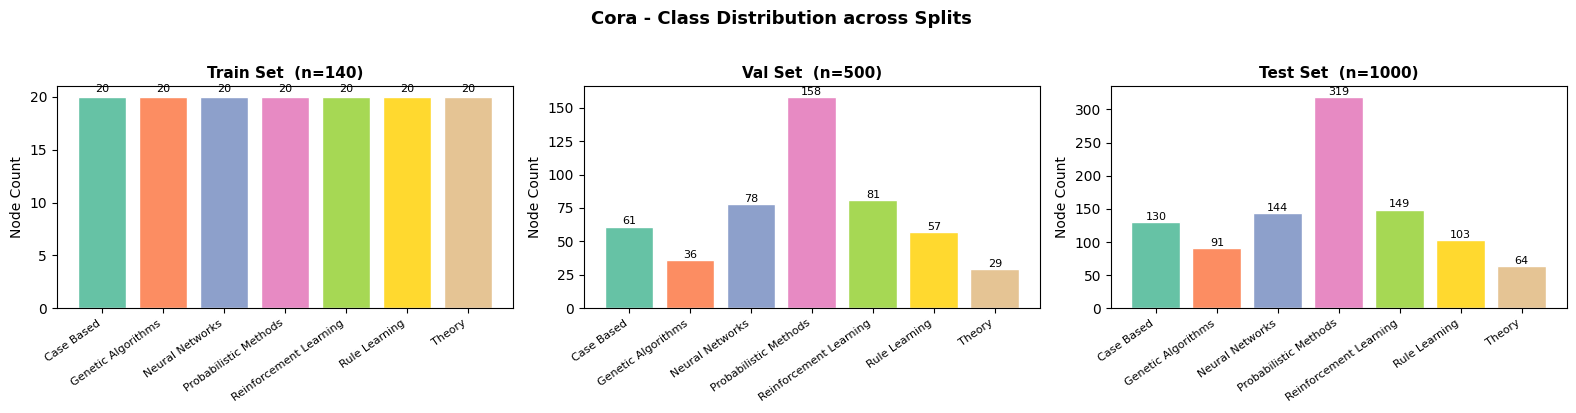

In [30]:
# Data division to Train, Val, Test

y_np = data.y.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette   = plt.cm.Set2.colors

for ax, mask_name, mask in [
    (axes[0], "Train", data.train_mask.cpu()),
    (axes[1], "Val",   data.val_mask.cpu()),
    (axes[2], "Test",  data.test_mask.cpu()),
]:
    labels   = y_np[mask.numpy()]
    counts   = np.bincount(labels, minlength=7)
    bars     = ax.bar(CLASS_NAMES, counts, color=palette, edgecolor="white")
    ax.set_title(f"{mask_name} Set  (n={mask.sum()})", fontweight="bold", fontsize=11)
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Node Count")
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3, str(cnt),
                ha="center", va="bottom", fontsize=8)

plt.suptitle("Cora - Class Distribution across Splits",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

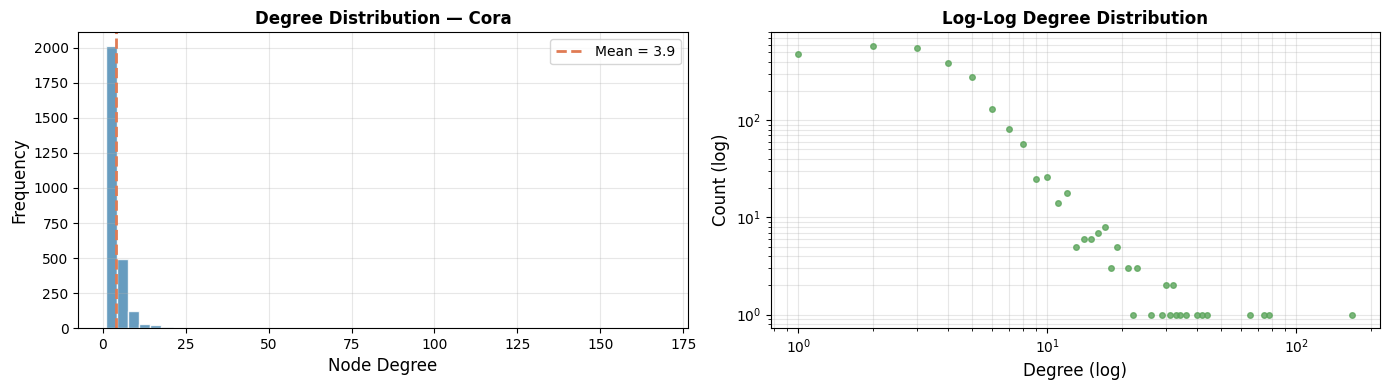

Mean degree  : 3.90
Max degree   : 168
Min degree   : 1
Median degree: 3.0


In [31]:
# Data Distribution graph plot

edge_index  = data.edge_index.cpu()
deg         = degree(edge_index[0], num_nodes=data.num_nodes).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(deg, bins=50, color="#4C8BB4", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Node Degree",  fontsize=12)
axes[0].set_ylabel("Frequency",    fontsize=12)
axes[0].set_title("Degree Distribution — Cora", fontweight="bold")
axes[0].axvline(deg.mean(), color="#E07B54", linestyle="--", linewidth=2,
                label=f"Mean = {deg.mean():.1f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log-log  (power-law check)
d_vals, counts = np.unique(deg, return_counts=True)
axes[1].loglog(d_vals, counts, "o", color="#5BA55B", markersize=4, alpha=0.8)
axes[1].set_xlabel("Degree (log)",   fontsize=12)
axes[1].set_ylabel("Count (log)",    fontsize=12)
axes[1].set_title("Log-Log Degree Distribution", fontweight="bold")
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

print(f"Mean degree  : {deg.mean():.2f}")
print(f"Max degree   : {deg.max():.0f}")
print(f"Min degree   : {deg.min():.0f}")
print(f"Median degree: {np.median(deg):.1f}")

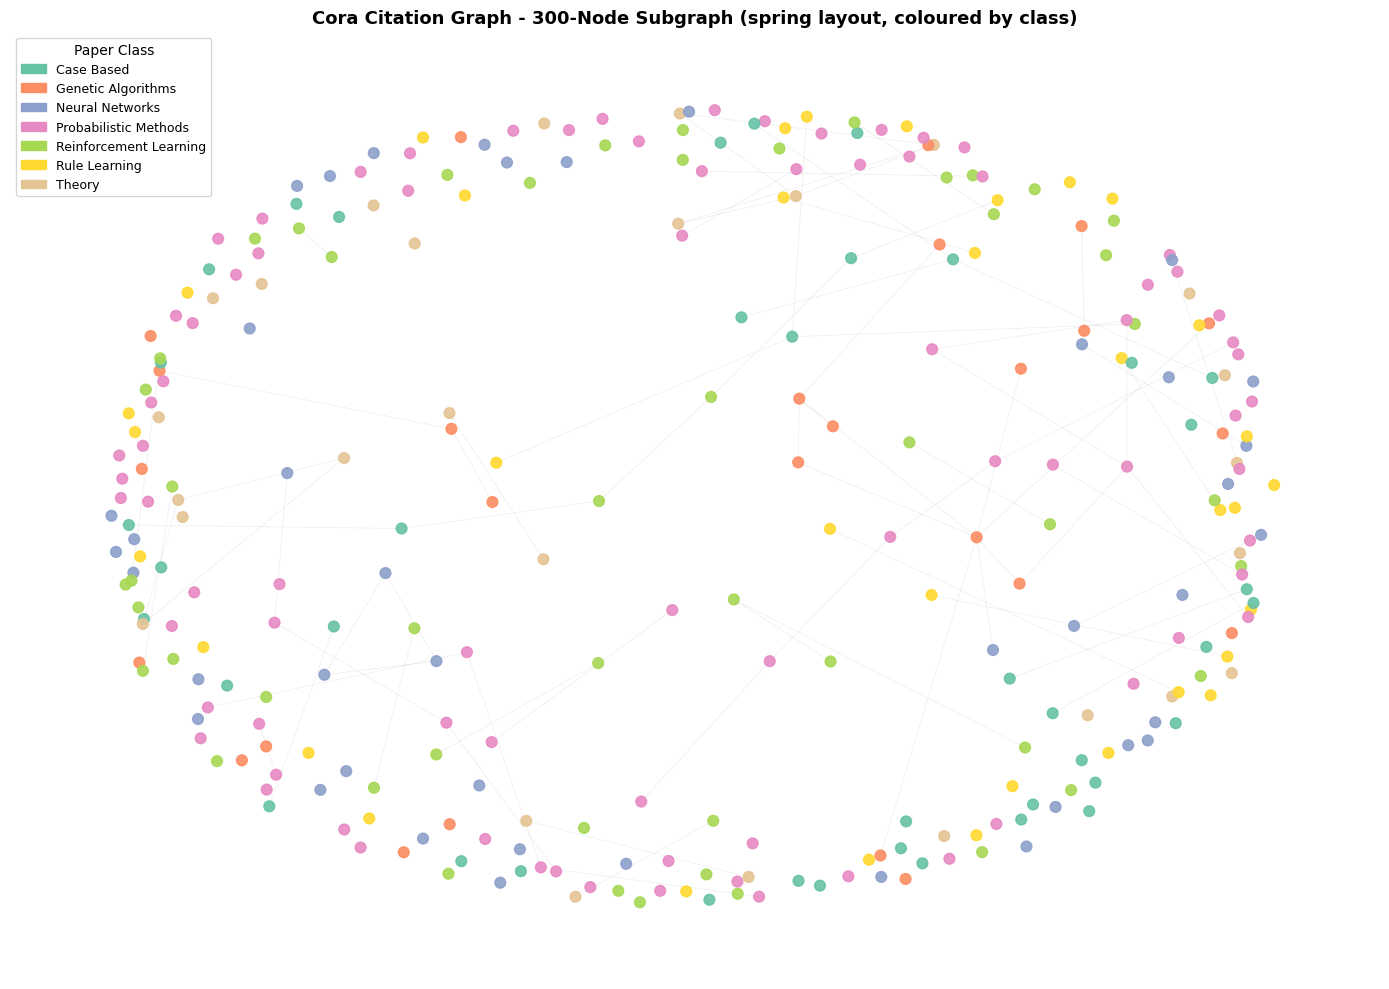

In [32]:
# Graph Visualizer
import networkx as nx
import matplotlib.patches as mpatches


SEED = 42

N_SAMPLE = 300
sample_nodes = set(range(N_SAMPLE))

ei_np  = data.edge_index.cpu().numpy()
mask   = np.isin(ei_np[0], list(sample_nodes)) & np.isin(ei_np[1], list(sample_nodes))
sub_ei = ei_np[:, mask]

G = nx.Graph()
G.add_nodes_from(range(N_SAMPLE))
G.add_edges_from(zip(sub_ei[0], sub_ei[1]))

labels_sample = data.y.cpu().numpy()[:N_SAMPLE]
node_colors   = [palette[l] for l in labels_sample]

fig, ax = plt.subplots(figsize=(14, 10))
pos     = nx.spring_layout(G, seed=SEED, k=0.4)

nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.15, width=0.5, edge_color="#888888")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=60, alpha=0.9)

legend_patches = [mpatches.Patch(color=palette[i], label=CLASS_NAMES[i])
                  for i in range(7)]
ax.legend(handles=legend_patches, loc="upper left", fontsize=9,
          title="Paper Class", title_fontsize=10)

ax.set_title(f"Cora Citation Graph - {N_SAMPLE}-Node Subgraph (spring layout, coloured by class)",
             fontsize=13, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.show()

### **Step 3: Model Definations**

In [33]:
# Implemented GCN
# Using Formula: H' = σ( D̃^{-1/2} Ã D̃^{-1/2} H W )

class GCNConv(nn.Module):
    """
    Single Graph Convolutional layer 
    Reference form Kipf & Welling, 2017
    Implements the normalised adjacency propagation
    """

    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=bias)
        self._reset_parameters()


    # Initializing Xavier / Glorot uniform
    def _reset_parameters(self):
        nn.init.xavier_uniform_(self.W.weight)
        if self.W.bias is not None:
            nn.init.zeros_(self.W.bias)

    @staticmethod
    def normalise_adjacency(edge_index, num_nodes):

        edge_index_sl, _ = add_self_loops(edge_index, num_nodes=num_nodes)

        # Degree of each node in Ã
        row      = edge_index_sl[0]
        deg      = degree(row, num_nodes=num_nodes, dtype=torch.float)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float("inf")] = 0.0   # Handle isolated nodes

        # Edge weights: d_i^{-0.5} * d_j^{-0.5}
        col      = edge_index_sl[1]
        norm_val = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # Build sparse tensor
        A_hat = torch.sparse_coo_tensor(
            edge_index_sl, norm_val,
            size=(num_nodes, num_nodes)
        )
        return A_hat

    def forward(self, x, A_hat):
        """
        x is (N, in_features) which is node feature matrix
        A_hat is (N, N) sparse which is pre-computed normalised adjacency
        """
        support = self.W(x)                          # (N, out_features)
        # Neighbourhood aggregation via sparse-dense matrix multiply
        out     = torch.sparse.mm(A_hat, support)    # (N, out_features)
        return out

In [34]:
#  GCN classifier

class GCN(nn.Module):
    """
    Architecture:
    Input (1433) -> GCNConv -> ReLU -> Dropout
    -> [optional hidden GCNConv blocks]
    -> GCNConv -> log-softmax
    """

    def __init__(self, in_features, hidden_sizes, num_classes, dropout=0.5):
        super().__init__()
        self.dropout = dropout

        layer_dims = [in_features] + hidden_sizes + [num_classes]
        self.convs  = nn.ModuleList([
            GCNConv(layer_dims[i], layer_dims[i + 1])
            for i in range(len(layer_dims) - 1)
        ])

    def forward(self, x, A_hat):
        for i, conv in enumerate(self.convs):
            x = conv(x, A_hat)
            if i < len(self.convs) - 1:          # No activation on final layer
                x = F.relu(x)
                x = F.dropout(x, p=self.dropout, training=self.training)
        return F.log_softmax(x, dim=1)            # (N, num_classes)

    def embed(self, x, A_hat):
        """Return activations of the second-to-last layer (for t-SNE visualisation)."""
        for i, conv in enumerate(self.convs[:-1]):
            x = F.relu(conv(x, A_hat))
        return x                                   # (N, hidden_sizes[-1])

In [35]:
#  pre comuting A^ and using it across all 

A_hat = GCNConv.normalise_adjacency(
    data.edge_index, num_nodes=data.num_nodes
).to(DEVICE)

print(f"Normalised Â shape: {A_hat.shape}  |  nnz: {A_hat._nnz():,}")

#  training and evaluation

#single training step
def train_epoch(model, optimizer, data, A_hat):
    model.train()
    optimizer.zero_grad()
    out  = model(data.x, A_hat)                           # Forward pass (all nodes)
    loss = F.nll_loss(out[data.train_mask],               # NLL over train nodes only
                      data.y[data.train_mask])
    loss.backward()
    optimizer.step()

    pred = out[data.train_mask].argmax(dim=1)
    acc  = (pred == data.y[data.train_mask]).float().mean().item()
    return loss.item(), acc


@torch.no_grad()
def evaluate(model, data, A_hat, mask):
    model.eval()
    out  = model(data.x, A_hat)
    loss = F.nll_loss(out[mask], data.y[mask]).item()
    pred = out[mask].argmax(dim=1)
    acc  = (pred == data.y[mask]).float().mean().item()
    return loss, acc

# COmplete training loop
def train_gcn(model, data, A_hat, epochs=200, lr=0.01,
              weight_decay=5e-4, verbose=True, log_every=25):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history   = {"train_loss": [], "train_acc": [],
                 "val_loss":   [], "val_acc":   []}

    best_val_acc = 0.0
    best_state   = None

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_epoch(model, optimizer, data, A_hat)
        v_loss, v_acc = evaluate(model, data, A_hat, data.val_mask)

        history["train_loss"].append(t_loss)
        history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)

        # checkpoint for best model
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_state   = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and epoch % log_every == 0:
            print(f"  Epoch {epoch:4d} | "
                  f"Train Loss: {t_loss:.4f}  Acc: {t_acc*100:5.1f}% | "
                  f"Val Loss: {v_loss:.4f}  Acc: {v_acc*100:5.1f}%")

    model.load_state_dict(best_state)
    return history

print("Training utilities defined.")

Normalised Â shape: torch.Size([2708, 2708])  |  nnz: 13,264
Training utilities defined.


## **Experiments**

### **Experiments & Hyperparameter Variations**

In [36]:
#  2-Layer GCN  (Kipf & Welling baseline)
#  Architecture: 1433 -> 64 -> 7

gcn2 = GCN(
    in_features=dataset.num_node_features,
    hidden_sizes=[64],
    num_classes=dataset.num_classes,
    dropout=0.5
).to(DEVICE)

total_params = sum(p.numel() for p in gcn2.parameters())
print(f"Parameters: {total_params:,}\n")

hist2 = train_gcn(gcn2, data, A_hat, epochs=200, lr=0.01,
                  weight_decay=5e-4, verbose=True, log_every=50)

_, test_acc2 = evaluate(gcn2, data, A_hat, data.test_mask)
print(f"\n>>> TEST ACCURACY (2-Layer GCN): {test_acc2*100:.2f}%")

Parameters: 92,231

  Epoch   50 | Train Loss: 0.4812  Acc:  96.4% | Val Loss: 0.9750  Acc:  79.6%
  Epoch  100 | Train Loss: 0.2515  Acc:  98.6% | Val Loss: 0.7907  Acc:  79.6%
  Epoch  150 | Train Loss: 0.2045  Acc:  99.3% | Val Loss: 0.7404  Acc:  79.2%
  Epoch  200 | Train Loss: 0.1738  Acc: 100.0% | Val Loss: 0.7192  Acc:  79.6%

>>> TEST ACCURACY (2-Layer GCN): 81.00%


In [37]:
# 3-Layer GCN
# Architecture: 1433 → 128 → 64 → 7

gcn3 = GCN(
    in_features=dataset.num_node_features,
    hidden_sizes=[128, 64],
    num_classes=dataset.num_classes,
    dropout=0.5
).to(DEVICE)

total_params = sum(p.numel() for p in gcn3.parameters())
print(f"Parameters: {total_params:,}\n")

hist3 = train_gcn(gcn3, data, A_hat, epochs=200, lr=0.01,
                  weight_decay=5e-4, verbose=True, log_every=50)

_, test_acc3 = evaluate(gcn3, data, A_hat, data.test_mask)
print(f"\n>>> TEST ACCURACY (3-Layer GCN): {test_acc3*100:.2f}%")

Parameters: 192,263

  Epoch   50 | Train Loss: 0.0682  Acc:  99.3% | Val Loss: 0.7106  Acc:  78.6%
  Epoch  100 | Train Loss: 0.0594  Acc:  99.3% | Val Loss: 0.7975  Acc:  76.6%
  Epoch  150 | Train Loss: 0.0535  Acc: 100.0% | Val Loss: 0.7757  Acc:  76.6%
  Epoch  200 | Train Loss: 0.0538  Acc:  99.3% | Val Loss: 0.7964  Acc:  79.2%

>>> TEST ACCURACY (3-Layer GCN): 78.90%


In [38]:
# 4-Layer GCN  (demonstrating over-smoothing)
# Architecture: 1433 → 128 → 64 → 32 → 7

gcn4 = GCN(
    in_features=dataset.num_node_features,
    hidden_sizes=[128, 64, 32],
    num_classes=dataset.num_classes,
    dropout=0.5
).to(DEVICE)

total_params = sum(p.numel() for p in gcn4.parameters())
print(f"Parameters: {total_params:,}\n")

hist4 = train_gcn(gcn4, data, A_hat, epochs=200, lr=0.01,
                  weight_decay=5e-4, verbose=True, log_every=50)

_, test_acc4 = evaluate(gcn4, data, A_hat, data.test_mask)
print(f"\n>>> TEST ACCURACY (4-Layer GCN): {test_acc4*100:.2f}%")

Parameters: 194,119

  Epoch   50 | Train Loss: 0.1122  Acc:  95.7% | Val Loss: 0.9696  Acc:  75.8%
  Epoch  100 | Train Loss: 0.0721  Acc:  97.9% | Val Loss: 1.0159  Acc:  77.0%
  Epoch  150 | Train Loss: 0.0465  Acc:  98.6% | Val Loss: 1.0195  Acc:  78.0%
  Epoch  200 | Train Loss: 0.0365  Acc:  99.3% | Val Loss: 1.1015  Acc:  76.2%

>>> TEST ACCURACY (4-Layer GCN): 79.00%


In [39]:
# Hyperparameter Grid Search

hp_configs = [
    {"hidden": [16], "dropout": 0.5, "lr": 0.01, "wd": 5e-4, "label":"H=16, drop=0.5"},
    {"hidden": [64], "dropout": 0.5, "lr": 0.01,  "wd": 5e-4, "label":"H=64, drop=0.5"},
    {"hidden": [64], "dropout": 0.3, "lr": 0.01,  "wd": 5e-4, "label":"H=64, drop=0.3"},
    {"hidden": [64], "dropout": 0.5, "lr": 0.001, "wd": 5e-4, "label":"H=64, lr=0.001"},
    {"hidden": [128], "dropout": 0.5, "lr": 0.01,  "wd": 5e-4, "label":"H=128, drop=0.5"},
    {"hidden": [64], "dropout": 0.5, "lr": 0.01,  "wd": 1e-3, "label":"H=64, wd=1e-3"},
]

hp_results = []
HP_EPOCHS  = 200

for cfg in hp_configs:
    torch.manual_seed(SEED)
    m = GCN(dataset.num_node_features, cfg["hidden"],
            dataset.num_classes, dropout=cfg["dropout"]).to(DEVICE)
    h = train_gcn(m, data, A_hat, epochs=HP_EPOCHS,
                  lr=cfg["lr"], weight_decay=cfg["wd"],
                  verbose=False)
    _, t_acc = evaluate(m, data, A_hat, data.test_mask)
    _, v_acc = evaluate(m, data, A_hat, data.val_mask)
    hp_results.append({
        "label":    cfg["label"],
        "val_acc":  round(v_acc * 100, 2),
        "test_acc": round(t_acc * 100, 2),
        "history":  h
    })
    print(f"  {cfg['label']:<30}  Val: {v_acc*100:.2f}%   Test: {t_acc*100:.2f}%")

print("\nGrid search complete.")

  H=16, drop=0.5                  Val: 81.60%   Test: 81.50%
  H=64, drop=0.5                  Val: 79.60%   Test: 81.40%
  H=64, drop=0.3                  Val: 79.80%   Test: 81.20%
  H=64, lr=0.001                  Val: 77.80%   Test: 80.10%
  H=128, drop=0.5                 Val: 80.00%   Test: 81.30%
  H=64, wd=1e-3                   Val: 79.80%   Test: 80.70%

Grid search complete.


## **Dataset Description**

This assigment use dataset loaded from torch_geometric.datasets.Planetoid.

This is Cora Citation Network dataset whihc 2708 scientific paper with 10,556 directed citation links. 

Only 140 nodes are labelled while 2568 are not labelled.

## **Results**

The results from those model can be plotted into the graphs:

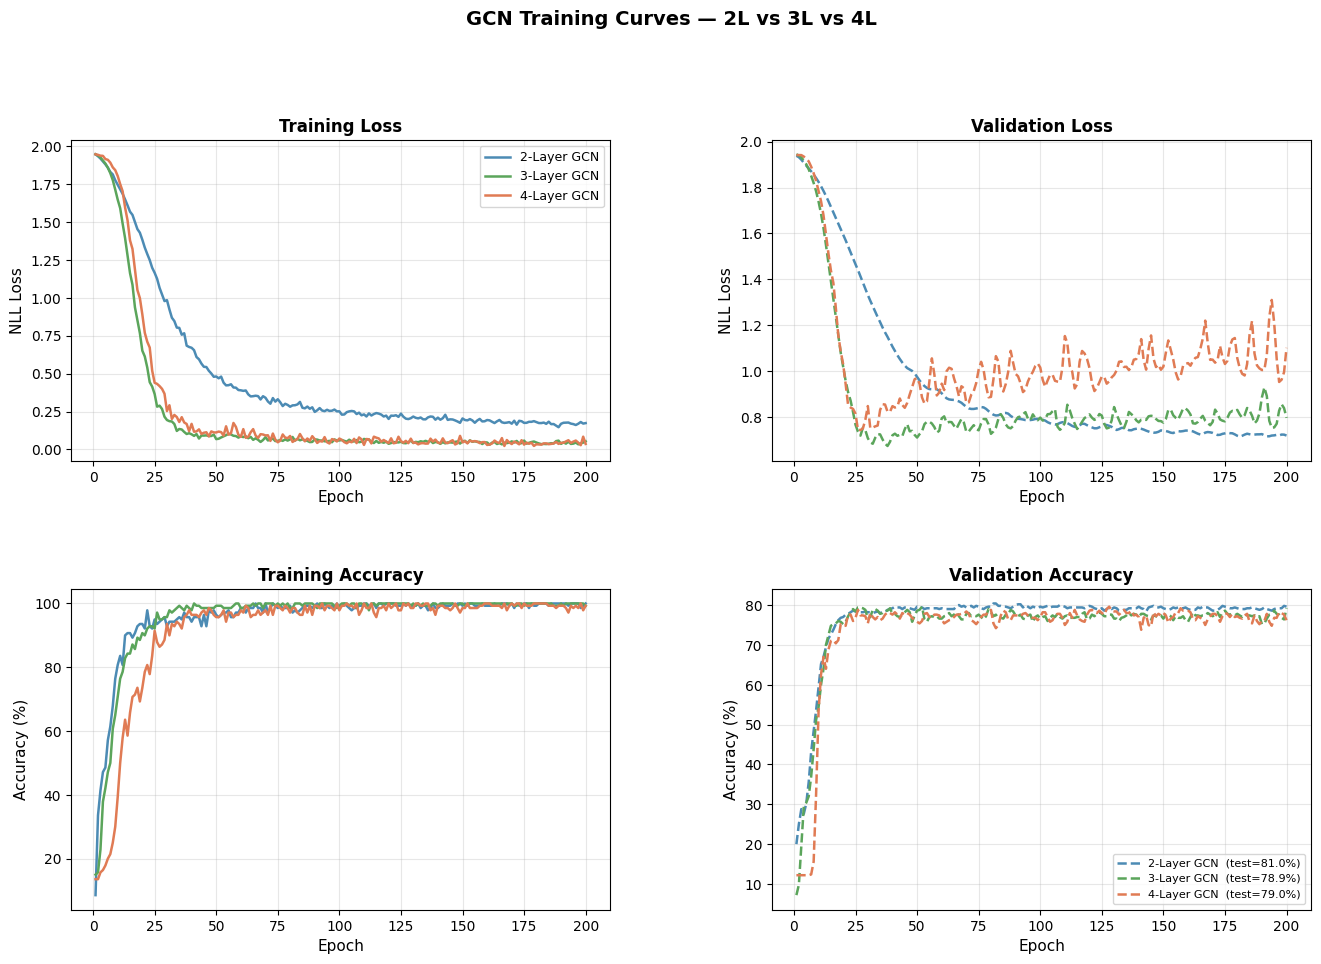

In [40]:
import matplotlib.gridspec  as gridspec

model_results = [
    ("2-Layer GCN", hist2, "#4C8BB4", test_acc2),
    ("3-Layer GCN", hist3, "#5BA55B", test_acc3),
    ("4-Layer GCN", hist4, "#E07B54", test_acc4),
]

epochs_range = range(1, 201)
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax_tl = fig.add_subplot(gs[0, 0])
ax_vl = fig.add_subplot(gs[0, 1])
ax_ta = fig.add_subplot(gs[1, 0])
ax_va = fig.add_subplot(gs[1, 1])

for name, h, col, test_acc in model_results:
    ax_tl.plot(epochs_range, h["train_loss"], color=col, linewidth=1.8, label=name)
    ax_vl.plot(epochs_range, h["val_loss"],   color=col, linewidth=1.8, linestyle="--")
    ax_ta.plot(epochs_range, [a*100 for a in h["train_acc"]], color=col, linewidth=1.8)
    ax_va.plot(epochs_range, [a*100 for a in h["val_acc"]],   color=col, linewidth=1.8, linestyle="--",
               label=f"{name}  (test={test_acc*100:.1f}%)")

for ax, title, ylabel in [
    (ax_tl, "Training Loss",      "NLL Loss"),
    (ax_vl, "Validation Loss",    "NLL Loss"),
    (ax_ta, "Training Accuracy",  "Accuracy (%)"),
    (ax_va, "Validation Accuracy","Accuracy (%)"),
]:
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel(ylabel,  fontsize=11)
    ax.set_title(title,    fontweight="bold", fontsize=12)
    ax.grid(True, alpha=0.3)

ax_tl.legend(fontsize=9)
ax_va.legend(fontsize=8, loc="lower right")

plt.suptitle("GCN Training Curves — 2L vs 3L vs 4L",
             fontsize=14, fontweight="bold", y=1.01)
plt.show()

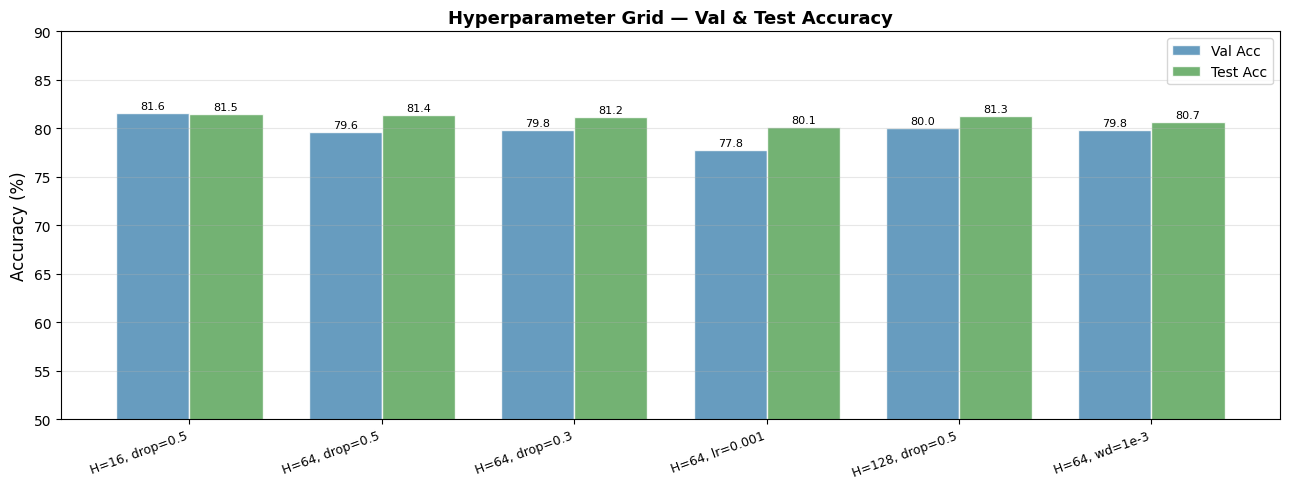

In [41]:
# Accuracy 

labels    = [r["label"]    for r in hp_results]
test_accs = [r["test_acc"] for r in hp_results]
val_accs  = [r["val_acc"]  for r in hp_results]

x     = np.arange(len(labels))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - width/2, val_accs,  width, label="Val Acc",  color="#4C8BB4", alpha=0.85, edgecolor="white")
b2 = ax.bar(x + width/2, test_accs, width, label="Test Acc", color="#5BA55B", alpha=0.85, edgecolor="white")

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f"{bar.get_height():.1f}",
            ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Hyperparameter Grid — Val & Test Accuracy",
             fontweight="bold", fontsize=13)
ax.set_ylim(50, 90)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

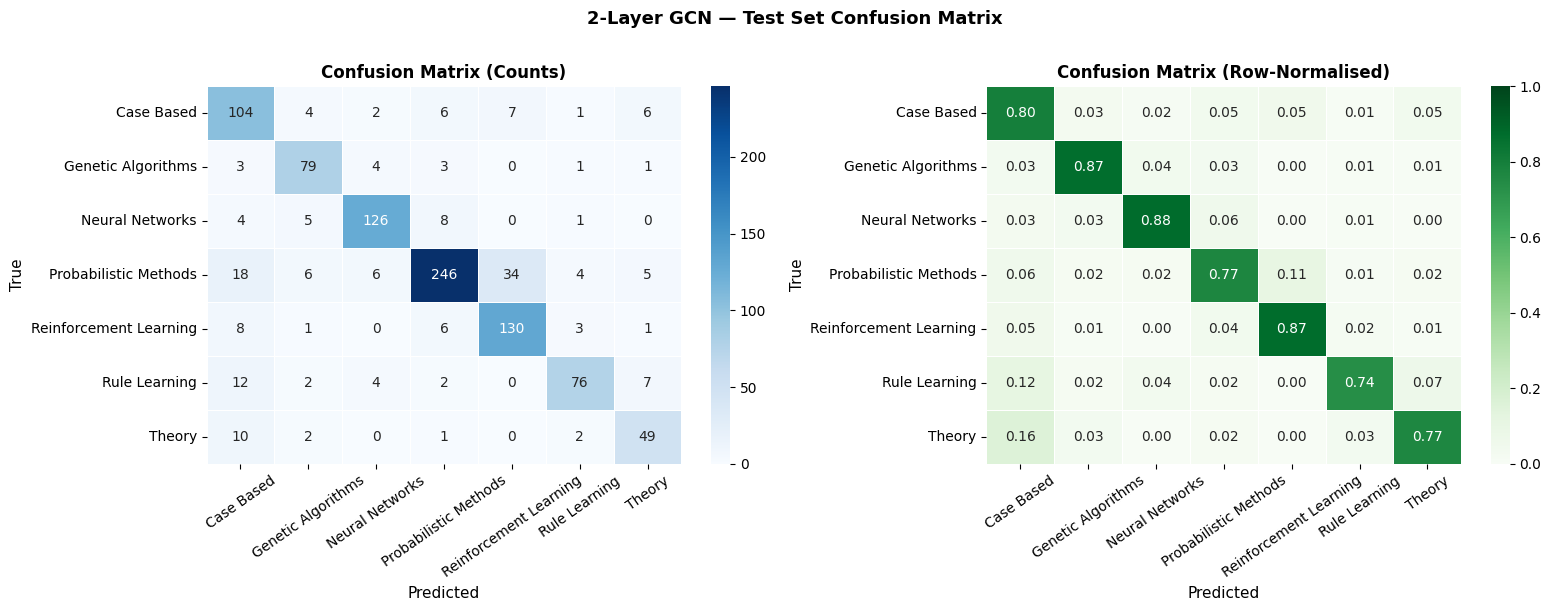


Classification Report (2-Layer GCN, Test Set):
                        precision    recall  f1-score   support

            Case Based      0.654     0.800     0.720       130
    Genetic Algorithms      0.798     0.868     0.832        91
       Neural Networks      0.887     0.875     0.881       144
 Probabilistic Methods      0.904     0.771     0.832       319
Reinforcement Learning      0.760     0.872     0.812       149
         Rule Learning      0.864     0.738     0.796       103
                Theory      0.710     0.766     0.737        64

              accuracy                          0.810      1000
             macro avg      0.797     0.813     0.801      1000
          weighted avg      0.822     0.810     0.812      1000



In [42]:
#  Confusion Matrix of best model which is 2 layer GCN
from sklearn.metrics import classification_report, confusion_matrix
import seaborn             as sns

@torch.no_grad()
def get_predictions(model, data, A_hat, mask):
    model.eval()
    out  = model(data.x, A_hat)
    pred = out[mask].argmax(dim=1).cpu().numpy()
    true = data.y[mask].cpu().numpy()
    return pred, true

pred2, true2 = get_predictions(gcn2, data, A_hat, data.test_mask)

cm = confusion_matrix(true2, pred2)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], linewidths=0.4)
axes[0].set_title("Confusion Matrix (Counts)",  fontweight="bold", fontsize=12)
axes[0].set_xlabel("Predicted", fontsize=11)
axes[0].set_ylabel("True",      fontsize=11)
axes[0].tick_params(axis="x", rotation=35)
axes[0].tick_params(axis="y", rotation=0)

# Normalised
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.4, vmin=0, vmax=1)
axes[1].set_title("Confusion Matrix (Row-Normalised)", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Predicted", fontsize=11)
axes[1].set_ylabel("True",      fontsize=11)
axes[1].tick_params(axis="x", rotation=35)
axes[1].tick_params(axis="y", rotation=0)

plt.suptitle("2-Layer GCN — Test Set Confusion Matrix",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\nClassification Report (2-Layer GCN, Test Set):")
print("=" * 75)
print(classification_report(true2, pred2, target_names=CLASS_NAMES, digits=3))

Computing t-SNE for raw node features...
Done.
Computing t-SNE for 2-Layer GCN embeddings...
Done.


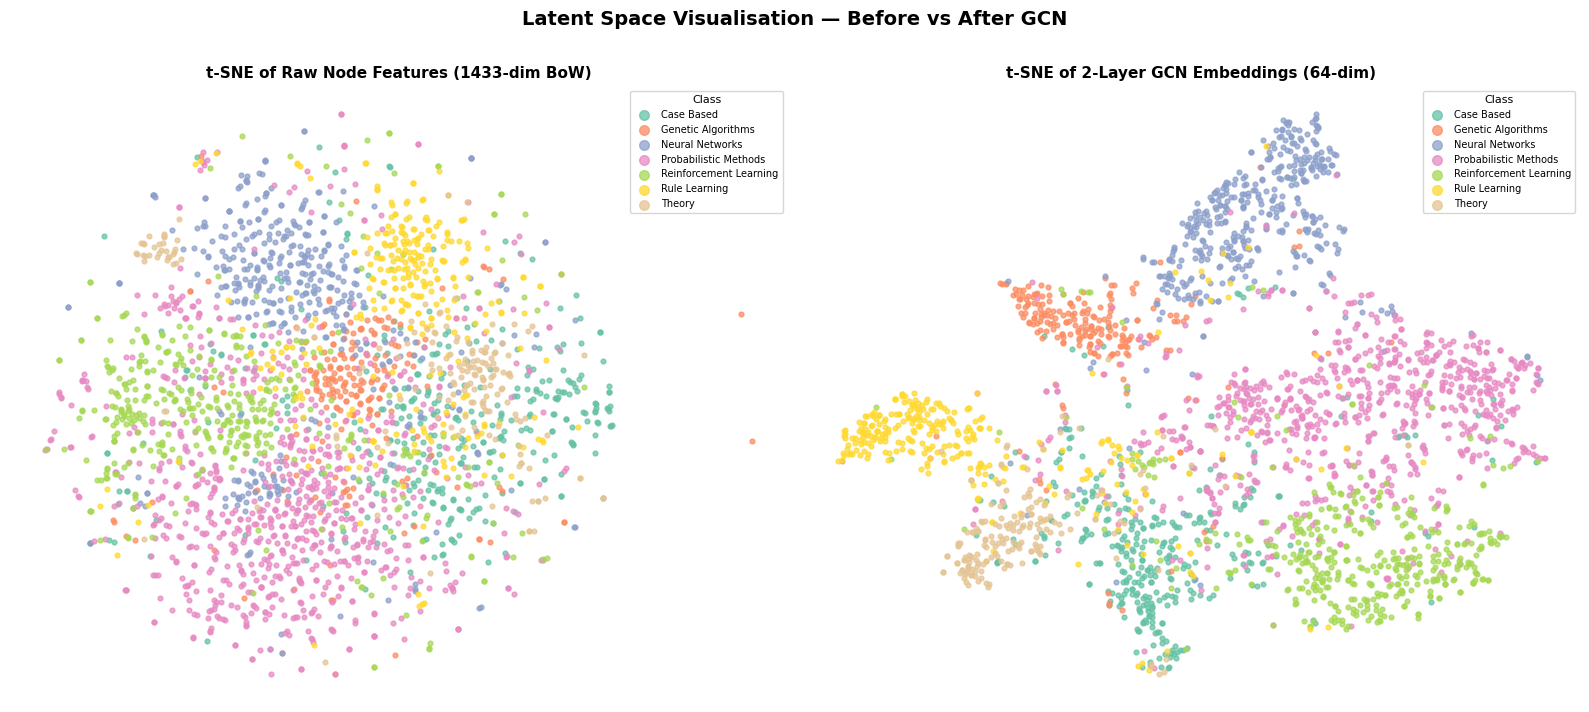

In [43]:
#  t-SNE Visualize and compare raw features vs GCN embeddings

from sklearn.manifold      import TSNE

@torch.no_grad()
def get_embeddings(model, data, A_hat):
    model.eval()
    return model.embed(data.x, A_hat).cpu().numpy()

print("Computing t-SNE for raw node features...")
raw_features = data.x.cpu().numpy()
tsne_raw     = TSNE(n_components=2, perplexity=40, random_state=SEED)
emb_raw      = tsne_raw.fit_transform(raw_features)
print("Done.")

print("Computing t-SNE for 2-Layer GCN embeddings...")
gcn_emb  = get_embeddings(gcn2, data, A_hat)
tsne_gcn = TSNE(n_components=2, perplexity=40, random_state=SEED)
emb_gcn  = tsne_gcn.fit_transform(gcn_emb)
print("Done.")


y_all = data.y.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, emb, title in [
    (axes[0], emb_raw, "t-SNE of Raw Node Features (1433-dim BoW)"),
    (axes[1], emb_gcn, "t-SNE of 2-Layer GCN Embeddings (64-dim)"),
]:
    for cls in range(7):
        mask = (y_all == cls)
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[palette[cls]], label=CLASS_NAMES[cls],
                   s=12, alpha=0.75)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.axis("off")
    ax.legend(fontsize=7, markerscale=2, loc="upper right",
              title="Class", title_fontsize=8)

plt.suptitle("Latent Space Visualisation — Before vs After GCN",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

  Depth 1: Test Acc = 71.40%
  Depth 2: Test Acc = 81.40%
  Depth 3: Test Acc = 80.30%
  Depth 4: Test Acc = 77.30%
  Depth 5: Test Acc = 71.60%
  Depth 6: Test Acc = 71.40%


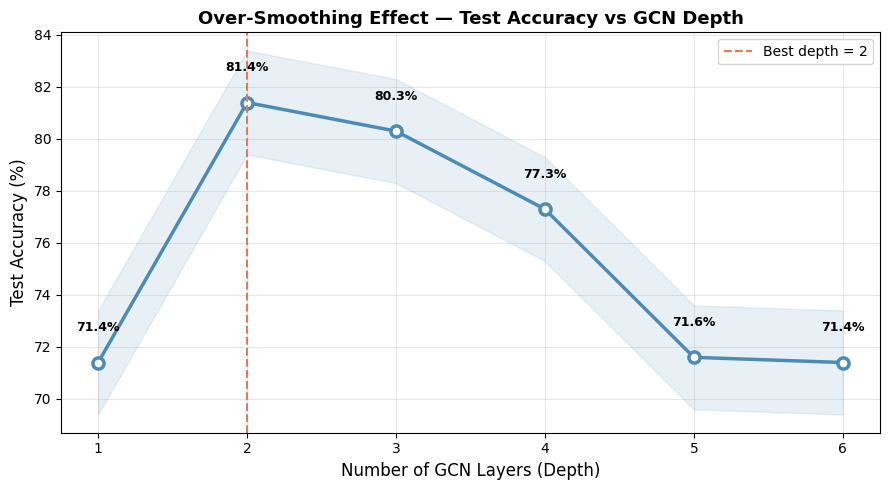

In [44]:
# Over-Smoothing - Test Acc vs GCN Depth

depth_results = []
MAX_DEPTH     = 6

for depth in range(1, MAX_DEPTH + 1):
    torch.manual_seed(SEED)
    hidden = [64] * (depth - 1) if depth > 1 else []   # depth-1 hidden layers, then output
    # Build: in -> 64 -> ... → 64 -> num_classes
    # For depth=1: in -> num_classes  (linear)
    if depth == 1:
        hidden_sizes = []
    else:
        hidden_sizes = [64] * (depth - 1)

    m = GCN(dataset.num_node_features, hidden_sizes,
            dataset.num_classes, dropout=0.5).to(DEVICE)
    train_gcn(m, data, A_hat, epochs=200, lr=0.01,
              weight_decay=5e-4, verbose=False)
    _, t_acc = evaluate(m, data, A_hat, data.test_mask)
    depth_results.append({"depth": depth, "test_acc": t_acc * 100})
    print(f"  Depth {depth}: Test Acc = {t_acc*100:.2f}%")

depths = [r["depth"]    for r in depth_results]
accs   = [r["test_acc"] for r in depth_results]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(depths, accs, "o-", color="#4C8BB4", linewidth=2.5,
        markersize=8, markerfacecolor="white", markeredgewidth=2.5)
ax.axvline(depths[np.argmax(accs)], color="#E07B54", linestyle="--",
           linewidth=1.5, label=f"Best depth = {depths[np.argmax(accs)]}")
ax.fill_between(depths, [a - 2 for a in accs], [a + 2 for a in accs],
                alpha=0.12, color="#4C8BB4")

for d, a in zip(depths, accs):
    ax.text(d, a + 1.2, f"{a:.1f}%", ha="center", fontsize=9, fontweight="bold")

ax.set_xlabel("Number of GCN Layers (Depth)", fontsize=12)
ax.set_ylabel("Test Accuracy (%)",            fontsize=12)
ax.set_title("Over-Smoothing Effect — Test Accuracy vs GCN Depth",
             fontweight="bold", fontsize=13)
ax.set_xticks(depths)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Analysis & Discussion**

The insights from the experiments is in mathematical calulation:

In [45]:
_, val_acc2 = evaluate(gcn2, data, A_hat, data.val_mask)
_, val_acc3 = evaluate(gcn3, data, A_hat, data.val_mask)
_, val_acc4 = evaluate(gcn4, data, A_hat, data.val_mask)

summary = pd.DataFrame([
    {
        "Model":        "2-Layer GCN",
        "Architecture": "1433->64->7",
        "Params":       sum(p.numel() for p in gcn2.parameters()),
        "Val Acc (%)":  round(val_acc2  * 100, 2),
        "Test Acc (%)":  round(test_acc2 * 100, 2),
    },
    {
        "Model":        "3-Layer GCN",
        "Architecture": "1433->128->64->7",
        "Params":       sum(p.numel() for p in gcn3.parameters()),
        "Val Acc (%)":  round(val_acc3  * 100, 2),
        "Test Acc (%)":  round(test_acc3 * 100, 2),
    },
    {
        "Model":        "4-Layer GCN",
        "Architecture": "1433->128->64->32->7",
        "Params":       sum(p.numel() for p in gcn4.parameters()),
        "Val Acc (%)":  round(val_acc4  * 100, 2),
        "Test Acc (%)":  round(test_acc4 * 100, 2),
    },
])

print("=" * 75)
print("Model Comparison Summary — Cora Node Classification")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
best_row = summary.loc[summary["Test Acc (%)"].idxmax()]
print(f"\nBest Test Accuracy: {best_row['Model']}  ({best_row['Test Acc (%)']:.2f}%)")

Model Comparison Summary — Cora Node Classification
      Model         Architecture  Params  Val Acc (%)  Test Acc (%)
2-Layer GCN          1433->64->7   92231         80.4          81.0
3-Layer GCN     1433->128->64->7  192263         79.6          78.9
4-Layer GCN 1433->128->64->32->7  194119         79.6          79.0

Best Test Accuracy: 2-Layer GCN  (81.00%)


## **Conclusion**

Thec conclusion that can be drawn from this assignments are:

1. 2-layer GCN achieved the best performance on the Cora dataset and showed that graph structure greatly improves semi-supervised node classification.
2. Normalised adjacency matrix helped stabilise feature propagation and preserve important node information during aggregation
3. Depth beyond 2–3 layers caused over-smoothing and also where node embeddings became too similar and accuracy dropped significantly
4. t-SNE visualisations showed that GCN embeddings formed much clearer class clusters than the original raw features

Thus, this assignment demonstrated how GNNs can effectively learn relational information and why they are widely used in areas like social networks, recommender systems, fraud detection, and drug discovery.